In [1]:
"""Run U2NETP segmentation on an image.

Usage:
    python main.py input.jpg                      # -> input_mask.png
    python main.py input.jpg out.png              # custom output
    python main.py input.jpg out.png --cutout     # also save transparent cutout

Weights: download u2netp.pth (~4.7MB) from the U-2-Net repo and place it
next to this script (or pass --weights path).
"""
import argparse
import os

import numpy as np
import torch
from PIL import Image

from model import U2NETP

INPUT_SIZE = 320  # U-2-Net standard input resolution


def load_model(weights, device):
    net = U2NETP(3, 1)
    net.load_state_dict(torch.load(weights, map_location=device))
    net.to(device).eval()
    return net


def preprocess(img):
    """PIL RGB image -> normalized (1,3,320,320) tensor (repo's RescaleT + ToTensorLab)."""
    im = img.resize((INPUT_SIZE, INPUT_SIZE), Image.BILINEAR)
    arr = np.array(im, dtype=np.float32) / 255.0
    arr = (arr - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
    arr = arr.transpose(2, 0, 1)  # HWC -> CHW
    return torch.from_numpy(arr).float().unsqueeze(0)


def segment(net, img, device):
    """Return a single-channel uint8 mask at the image's original size."""
    x = preprocess(img).to(device)
    with torch.no_grad():
        d0 = net(x)[0]
    pred = d0[0, 0]
    pred = (pred - pred.min()) / (pred.max() - pred.min() + 1e-8)  # normalize
    mask = (pred.cpu().numpy() * 255).astype(np.uint8)
    return Image.fromarray(mask).resize(img.size, Image.BILINEAR)

In [2]:
device = 'cpu'
weights = 'u2netp.pth'
inputimg = '/Users/rzt/Documents/env1/annyfit/p1.jpg'

net = load_model(weights, device)
img = Image.open(inputimg).convert("RGB")
mask = segment(net, img, device)

/Users/rzt/Documents/env1/annyfit/u2net_seg/model.py:23: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  src = F.upsample(src,size=tar.shape[2:],mode='bilinear')


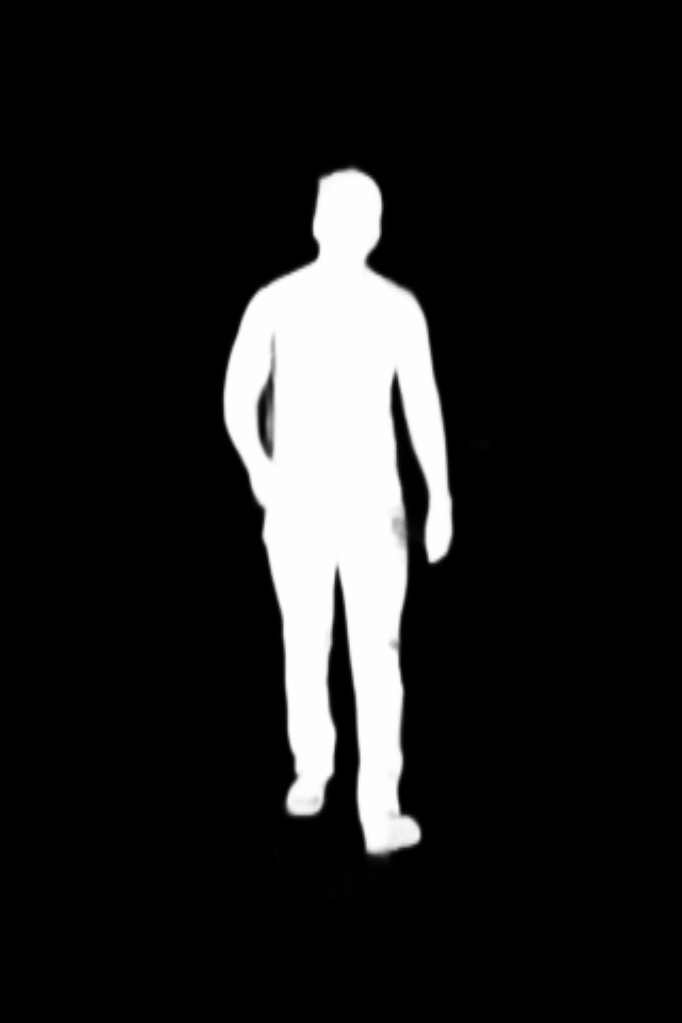

In [3]:
mask

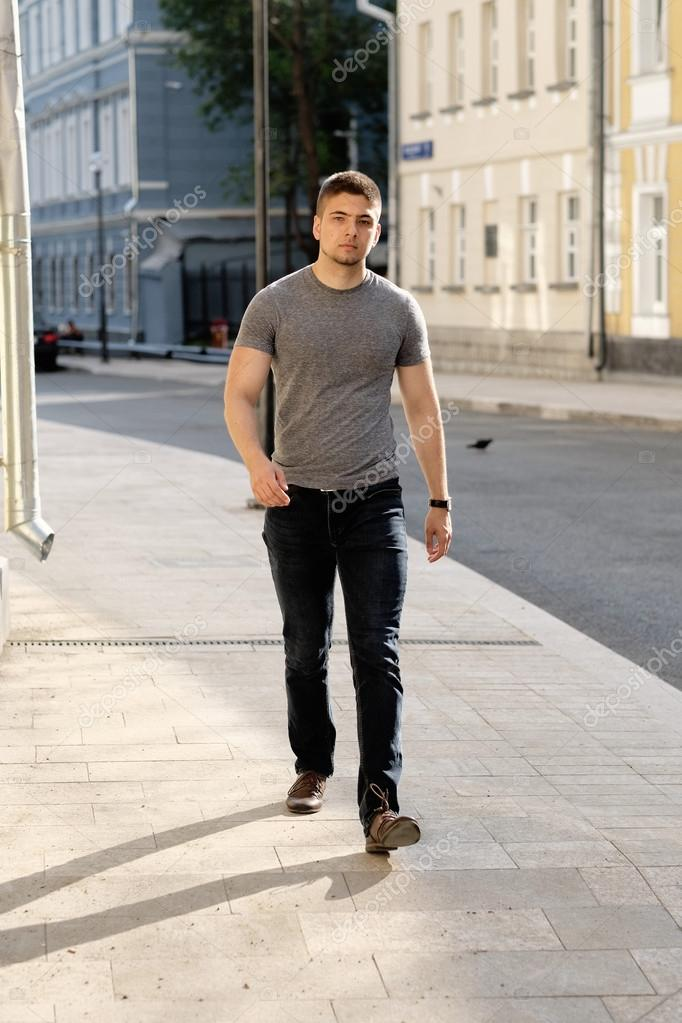

In [4]:
img